<a href="https://colab.research.google.com/github/Ragorrison/CASOS-DE-ESTUDIO/blob/main/notebooks/Cluster1Kmeans_2026_febrero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
# para que quede bonita las salidas
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score


In [ ]:
from google.colab import files
carga=files.upload()

Saving hatcoclase.xlsx to hatcoclase.xlsx


In [ ]:

data1=pd.read_excel(carga['hatcoclase.xlsx'])
data1.head()

/tmp/ipython-input-3039024454.py:1: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  data1=pd.read_excel(carga['hatcoclase.xlsx'])


,Ventrega,Nprecio,Flexprecio,ImagenF,Servicio,ImagenFV,CalidadP
0,4.1,0.6,6.9,4.7,2.4,2.3,5.2
1,1.8,3.0,6.3,6.6,2.5,4.0,8.4
2,3.4,5.2,5.7,6.0,4.3,2.7,8.2
3,2.7,1.0,7.1,5.9,1.8,2.3,7.8
4,6.0,0.9,9.6,7.8,3.4,4.6,4.5


In [ ]:
data1.columns

Index(['Ventrega', 'Nprecio', 'Flexprecio', 'ImagenF', 'Servicio', 'ImagenFV',
       'CalidadP'],
      dtype='object')

In [ ]:
dataResp=data1.copy()
dataResp.head()

,Ventrega,Nprecio,Flexprecio,ImagenF,Servicio,ImagenFV,CalidadP
0,4.1,0.6,6.9,4.7,2.4,2.3,5.2
1,1.8,3.0,6.3,6.6,2.5,4.0,8.4
2,3.4,5.2,5.7,6.0,4.3,2.7,8.2
3,2.7,1.0,7.1,5.9,1.8,2.3,7.8
4,6.0,0.9,9.6,7.8,3.4,4.6,4.5


In [ ]:
data2=StandardScaler().fit_transform(data1)

In [ ]:
# Método no jerárquico

kmeans = KMeans(n_clusters=3)
data1["Cluster"] = kmeans.fit_predict(data1)
data1["Cluster"] = data1["Cluster"].astype("category")

data1




,Ventrega,Nprecio,Flexprecio,ImagenF,Servicio,ImagenFV,CalidadP,Cluster
0,4.1,0.6,6.9,4.7,2.4,2.3,5.2,0
1,1.8,3.0,6.3,6.6,2.5,4.0,8.4,2
2,3.4,5.2,5.7,6.0,4.3,2.7,8.2,2
3,2.7,1.0,7.1,5.9,1.8,2.3,7.8,0
4,6.0,0.9,9.6,7.8,3.4,4.6,4.5,1
...,...,...,...,...,...,...,...,...
95,0.6,1.6,6.4,5.0,0.7,2.1,8.4,2
96,6.1,0.5,9.2,4.8,3.3,2.8,7.1,1
97,2.0,2.8,5.2,5.0,2.4,2.7,8.4,2
98,3.1,2.2,6.7,6.8,2.6,2.9,8.4,2


In [ ]:
data1.to_excel('dataosPB.xlsx',index=False)

In [ ]:
files.download('dataosPB.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
kmeans.cluster_centers_

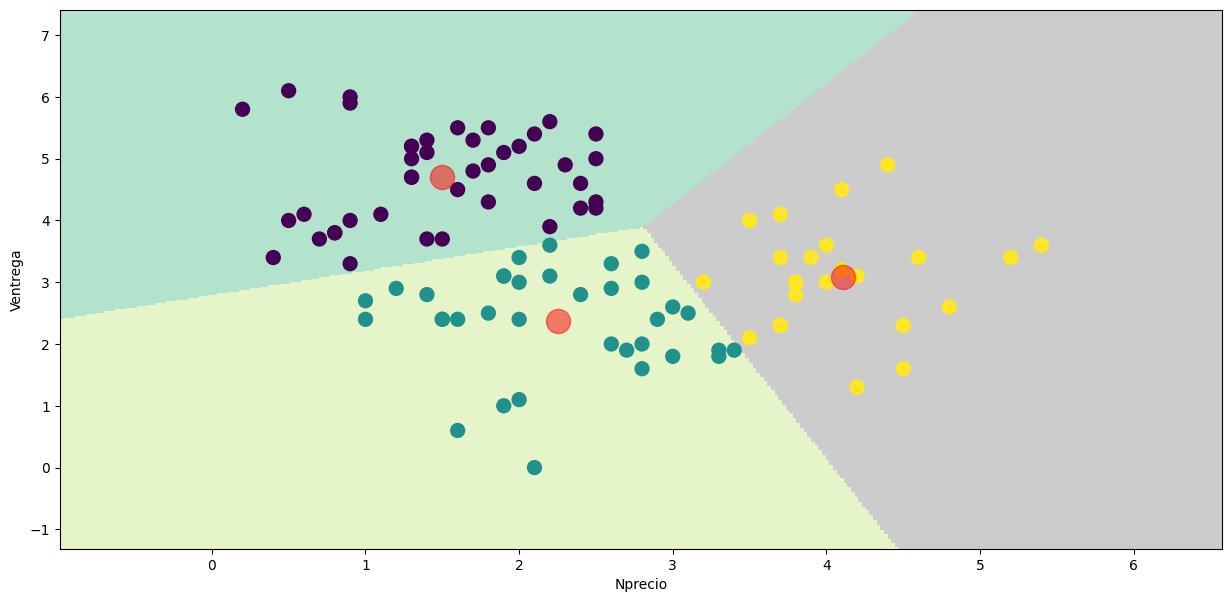

In [ ]:
plt.figure(1 , figsize = (15 , 7) )
plt.clf()

# Extraer las características para graficar (Nprecio y Ventrega)
# Se desea visualizar la agrupación en el espacio 2D de 'Nprecio' y 'Ventrega'.
# Nota: El modelo 'kmeans' previamente ajustado en el notebook se entrenó en 9 dimensiones (data3).
# Para graficar correctamente los límites de decisión 2D, se agrupa en función de 'Nprecio' y 'Ventrega'.
# Esto significa que las agrupaciones mostradas aquí serán específicas de estas dos características y pueden diferir
# de la agrupación en 9 dimensiones de 'data1["Grupo"]'.
#
X_plot_features = data1[['Nprecio', 'Ventrega']]

# Scale these two features
scaler_2d = StandardScaler()
X_plot_scaled = scaler_2d.fit_transform(X_plot_features)

# Create a new KMeans model for 2D visualization and fit it
kmeans_2d = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans_2d.fit(X_plot_scaled)

# Get the cluster labels from this 2D clustering
labels1 = kmeans_2d.labels_

# Get the centroids from this 2D clustering (scaled)
centroids1_scaled = kmeans_2d.cluster_centers_

# Create meshgrid in the scaled feature space
x_min, x_max = X_plot_scaled[:, 0].min() - 1, X_plot_scaled[:, 0].max() + 1
y_min, y_max = X_plot_scaled[:, 1].min() - 1, X_plot_scaled[:, 1].max() + 1
xx_scaled, yy_scaled = np.meshgrid(np.arange(x_min, x_max, 0.02),
                                   np.arange(y_min, y_max, 0.02))

# Predict cluster for each point in the scaled meshgrid
Z = kmeans_2d.predict(np.c_[xx_scaled.ravel(), yy_scaled.ravel()])
Z = Z.reshape(xx_scaled.shape)

# Inverse transform meshgrid coordinates and centroids back to the original scale for plotting
xx_original, yy_original = scaler_2d.inverse_transform(np.c_[xx_scaled.ravel(), yy_scaled.ravel()]).T
xx_original = xx_original.reshape(xx_scaled.shape)
yy_original = yy_original.reshape(yy_scaled.shape)

centroids1 = scaler_2d.inverse_transform(centroids1_scaled)

plt.imshow(Z , interpolation='nearest',
           extent=(xx_original.min(), xx_original.max(), yy_original.min(), yy_original.max()), # Use original scale extents
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

# Scatter plot the original data points
plt.scatter(x = X_plot_features['Nprecio'], y = X_plot_features['Ventrega'], c = labels1, s = 100)

# Scatter plot the centroids (on original scale)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Ventrega') , plt.xlabel('Nprecio')
plt.show()

In [ ]:
#Ahora con los datos estandarizados, recomendable cuando la svariables están
#en diferentes unidades, por ejemplo, peso, volúmene,..
data3=StandardScaler().fit_transform(data1)
data3

In [ ]:
# Método no jerárquico

kmeans2 = KMeans(n_clusters=3)
data1["Grupo"] = kmeans2.fit_predict(data3)
data1["Grupo"] = data1["Grupo"].astype("category")

data1

,Ventrega,Nprecio,Flexprecio,ImagenF,Servicio,ImagenFV,CalidadP,Cluster,Grupo
0,4.1,0.6,6.9,4.7,2.4,2.3,5.2,1,0
1,1.8,3.0,6.3,6.6,2.5,4.0,8.4,2,1
2,3.4,5.2,5.7,6.0,4.3,2.7,8.2,2,1
3,2.7,1.0,7.1,5.9,1.8,2.3,7.8,2,2
4,6.0,0.9,9.6,7.8,3.4,4.6,4.5,0,0
...,...,...,...,...,...,...,...,...,...
95,0.6,1.6,6.4,5.0,0.7,2.1,8.4,2,2
96,6.1,0.5,9.2,4.8,3.3,2.8,7.1,0,0
97,2.0,2.8,5.2,5.0,2.4,2.7,8.4,2,2
98,3.1,2.2,6.7,6.8,2.6,2.9,8.4,2,1


#Centroides

In [ ]:
kmeans2.cluster_centers_

array([[ 0.83072943, -0.59923473,  0.77915788, -0.12821685,  0.28777722,
        -0.07315747, -0.68182842, -0.93047299],
       [-0.39733689,  1.23708243, -0.82666582,  0.70412971,  0.65227662,
         0.52990014,  0.64106141,  0.9275698 ],
       [-0.97249598, -0.28417574, -0.44131339, -0.51651384, -1.15606371,
        -0.42759696,  0.47157627,  0.58886408]])

##Investigación 1:
Realice un escrito sobre el concepto de silueta en clustering, para qué se usa,
Use la biblioteca

from sklearn.metrics import silhouette_samples, silhouette_score
Para construir la silueta de su algoritmo kmeans

In [ ]:
labels=kmeans.labels_
silhouette_avg = silhouette_score(dataResp,labels)

##Investigación 2

Explique en un escrito el próposito de la siguiente celda de código



In [ ]:
kmeans_kwargs = {"init": "random","n_init": 10,"max_iter": 300,"random_state": 42}

# A list holds the SSE values for each k
sse = []
for k in range(1, 7):
  kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
  kmeans.fit(dataResp)
  sse.append(kmeans.inertia_)

In [ ]:
from sklearn.metrics import silhouette_score
# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

In [ ]:
#plt.style.use("fivethirtyeight")
plt.style.use('dark_background')
#plt.style.use('ggplot')
plt.plot(range(1,7), sse)
plt.xticks(range(1, 7))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()